--2025-05-27 08:08:38--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz [following]
--2025-05-27 08:08:39--  https://thor.robots.ox.ac.uk/flowers/102/102flowers.tgz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344862509 (329M) [application/octet-stream]
Saving to: ‘102flowers.tgz’

102flowers.tgz      100%[===================>] 328.89M  21.5MB/s    in 16s     

2025-05-27 08:08:56 (20.3 MB/s) - ‘102flowers.tgz’ saved [344862509/344862509]

--2025-05-27 08:08:56--  https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels

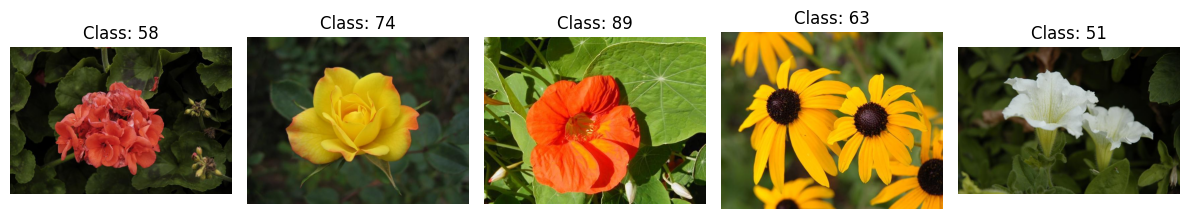

In [4]:
!pip install scipy --quiet
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz
!wget https://www.robots.ox.ac.uk/~vgg/data/flowers/102/imagelabels.mat

import tarfile
with tarfile.open('102flowers.tgz', 'r:gz') as tar:
    tar.extractall()

import scipy.io
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

labels = scipy.io.loadmat('imagelabels.mat')['labels'][0]
image_dir = 'jpg'
image_files = sorted(os.listdir(image_dir))
data = list(zip(image_files, labels))

random.seed(42)
random.shuffle(data)

n = len(data)
train_data = data[:int(0.7 * n)]
val_data = data[int(0.7 * n):int(0.85 * n)]
test_data = data[int(0.85 * n):]

train_files = set(f for f, _ in train_data)
val_files = set(f for f, _ in val_data)
test_files = set(f for f, _ in test_data)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))
print("Overlap train/val:", len(train_files & val_files))
print("Overlap train/test:", len(train_files & test_files))
print("Overlap val/test:", len(val_files & test_files))

plt.figure(figsize=(12, 6))
for i, (img_name, label) in enumerate(random.sample(train_data, 5)):
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f'Class: {label}')
    plt.axis('off')
plt.tight_layout()
plt.show()


Train Loss: 0.497 Acc: 85.59% | Val Loss: 3.256 Acc: 37.95%:  67%|██████▋   | 10/15 [05:37<02:48, 33.78s/it]


Early stopping triggered after 11 epochs.


Test accuracy: 37.75%


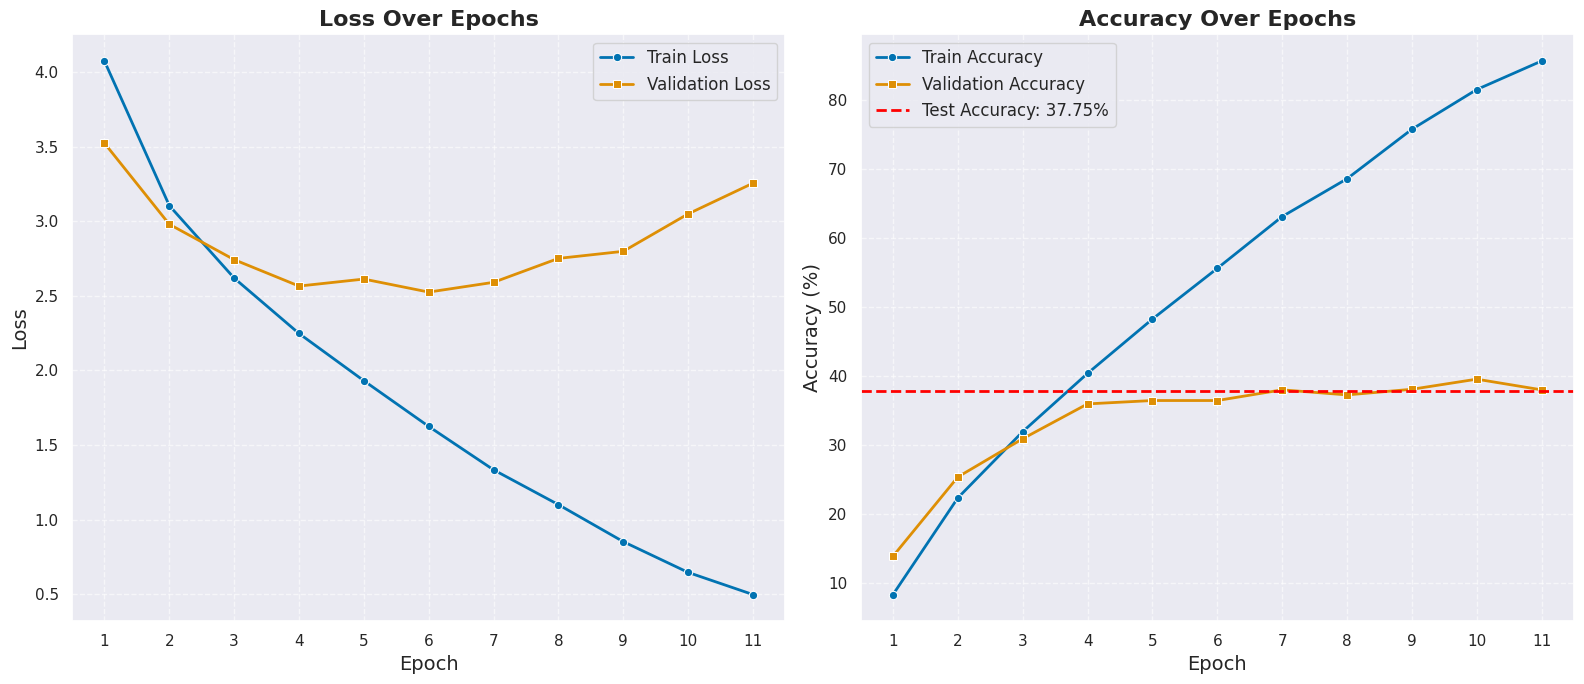

In [5]:
import tarfile
import scipy.io
import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import trange
import torchvision.transforms as transforms
import copy

with tarfile.open('102flowers.tgz', 'r:gz') as tar:
    tar.extractall()

class Flowers102Dataset(Dataset):
    def __init__(self, data_list, image_dir, transform=None):
        self.data_list = data_list
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        img_name, label = self.data_list[idx]
        img_path = os.path.join(self.image_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = label - 1
        return img, label

class Flower102Classifier:
    def __init__(self, data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                 batch_size=64, learning_rate=0.001, num_epochs=30, early_stop_patience=5):
        assert abs(train_pct + val_pct + test_pct - 1.0) < 1e-6
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.early_stop_patience = early_stop_patience
        self.image_dir = image_dir
        random.seed(42)
        random.shuffle(data)
        n = len(data)
        train_end = int(train_pct * n)
        val_end = train_end + int(val_pct * n)
        self.train_data = data[:train_end]
        self.val_data = data[train_end:val_end]
        self.test_data = data[val_end:]
        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        self.train_dataset = Flowers102Dataset(self.train_data, image_dir, transform)
        self.val_dataset = Flowers102Dataset(self.val_data, image_dir, transform)
        self.test_dataset = Flowers102Dataset(self.test_data, image_dir, transform)
        self.train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        self.val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        self.test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        num_classes = len(set(label for _, label in data))
        self.model = self._build_model(num_classes)
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        self.loss_fn = nn.CrossEntropyLoss()

    def _build_model(self, num_classes):
        return nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def _train_one_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        for images, labels in self.train_loader:
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_fn(outputs, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.train_loader), 100 * correct / len(self.train_loader.dataset)

    def _validate_one_epoch(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in self.val_loader:
                outputs = self.model(images)
                loss = self.loss_fn(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.val_loader), 100 * correct / len(self.val_loader.dataset)

    def train(self):
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_state = None

        for epoch in (pbar := trange(self.num_epochs)):
            train_loss, train_acc = self._train_one_epoch()
            val_loss, val_acc = self._validate_one_epoch()
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)
            pbar.set_description(f"Train Loss: {train_loss:.3f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.3f} Acc: {val_acc:.2f}%")
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                best_model_state = copy.deepcopy(self.model.state_dict())
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= self.early_stop_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                break
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

    def test(self):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                outputs = self.model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        accuracy = 100 * correct / len(self.test_loader.dataset)
        print(f'Test accuracy: {accuracy:.2f}%')
        self.test_accuracy = accuracy
        return accuracy

    def plot_training(self):
        sns.set(style="darkgrid", palette="colorblind")
        epochs = np.arange(1, len(self.train_losses) + 1)
        plt.figure(figsize=(16, 7))
        plt.subplot(1, 2, 1)
        sns.lineplot(x=epochs, y=self.train_losses, marker="o", label='Train Loss', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_losses, marker="s", label='Validation Loss', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Loss', fontsize=14)
        plt.title('Loss Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.subplot(1, 2, 2)
        sns.lineplot(x=epochs, y=self.train_accuracies, marker="o", label='Train Accuracy', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_accuracies, marker="s", label='Validation Accuracy', linewidth=2)
        if hasattr(self, 'test_accuracy'):
            plt.axhline(y=self.test_accuracy, color='red', linestyle='--', label=f'Test Accuracy: {self.test_accuracy:.2f}%', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Accuracy (%)', fontsize=14)
        plt.title('Accuracy Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

labels = scipy.io.loadmat('imagelabels.mat')['labels'][0]
image_dir = 'jpg'
image_files = sorted(os.listdir(image_dir))
data = list(zip(image_files, labels))
classifier = Flower102Classifier(data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                                 batch_size=64, num_epochs=15, early_stop_patience=5)
classifier.train()
classifier.test()
classifier.plot_training()


Train Loss: 1.646 Acc: 52.01% | Val Loss: 2.372 Acc: 41.04%: 100%|██████████| 15/15 [07:42<00:00, 30.84s/it]


Test accuracy: 40.93%


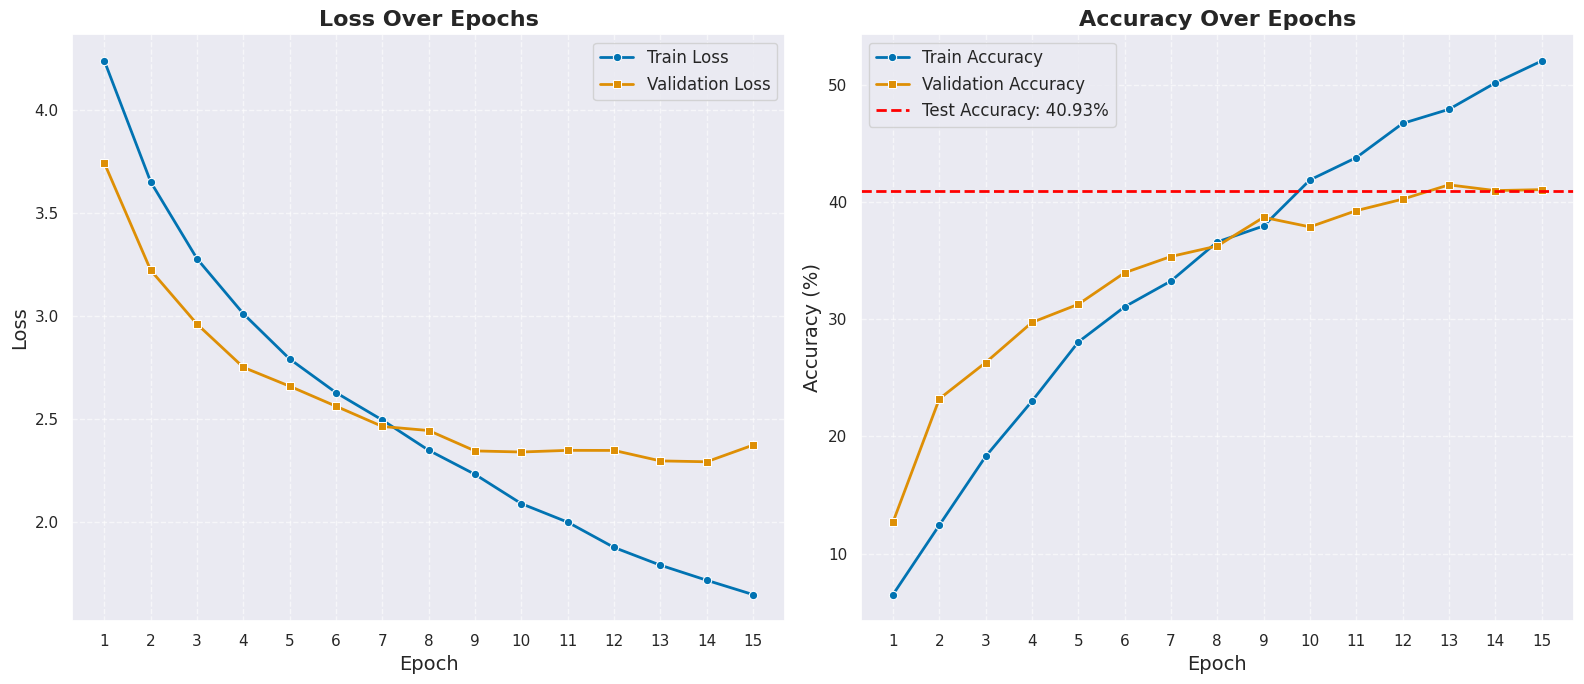

In [11]:
class RegularizedModel(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class RegularizedFlower102Classifier(Flower102Classifier):
    def _build_model(self, num_classes):
        return RegularizedModel(num_classes, dropout_rate=0.5)

    def __init__(self, data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                 batch_size=64, learning_rate=0.001, num_epochs=30, early_stop_patience=5,
                 weight_decay=1e-4):
        super().__init__(data, image_dir, train_pct, val_pct, test_pct,
                         batch_size, learning_rate, num_epochs, early_stop_patience)
        self.model = self._build_model(len(set(label for _, label in data)))
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay)

regularized_classifier = RegularizedFlower102Classifier(data, image_dir,
    train_pct=0.7, val_pct=0.15, test_pct=0.15,
    batch_size=64, num_epochs=15, early_stop_patience=5, weight_decay=1e-4)

regularized_classifier.train()
regularized_classifier.test()
regularized_classifier.plot_training()


Train Loss: 1.290 Acc: 59.70% | Val Loss: 2.658 Acc: 39.09%:  70%|███████   | 21/30 [11:23<04:53, 32.56s/it]


Early stopping triggered after 22 epochs.


Test accuracy: 40.68%


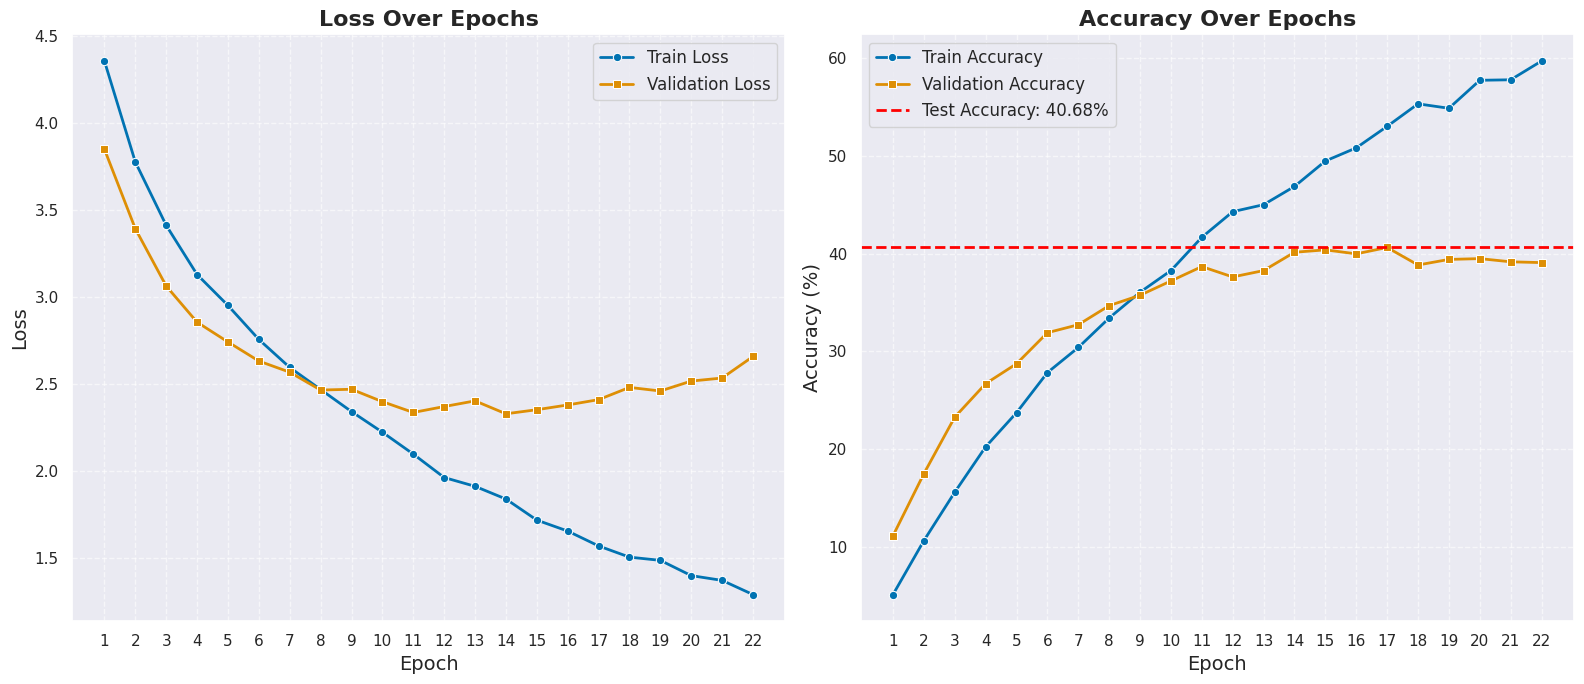

In [15]:
class RegularizedModel(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class RegularizedFlower102Classifier(Flower102Classifier):
    def _build_model(self, num_classes):
        return RegularizedModel(num_classes, dropout_rate=0.5)

    def __init__(self, data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                 batch_size=64, learning_rate=0.001, num_epochs=30, early_stop_patience=5,
                 weight_decay=1e-4):
        super().__init__(data, image_dir, train_pct, val_pct, test_pct,
                         batch_size, learning_rate, num_epochs, early_stop_patience)
        self.model = self._build_model(len(set(label for _, label in data)))
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=weight_decay)

regularized_classifier = RegularizedFlower102Classifier(data, image_dir,
    train_pct=0.7, val_pct=0.15, test_pct=0.15,
    batch_size=64, num_epochs=30, early_stop_patience=8, weight_decay=1e-4)

regularized_classifier.train()
regularized_classifier.test()
regularized_classifier.plot_training()


**SGD very simple model**

Train Loss: 4.503 Acc: 3.30% | Val Loss: 4.528 Acc: 3.42%:  73%|███████▎  | 11/15 [08:49<03:12, 48.09s/it]


Early stopping triggered after 12 epochs.


Test accuracy: 3.01%


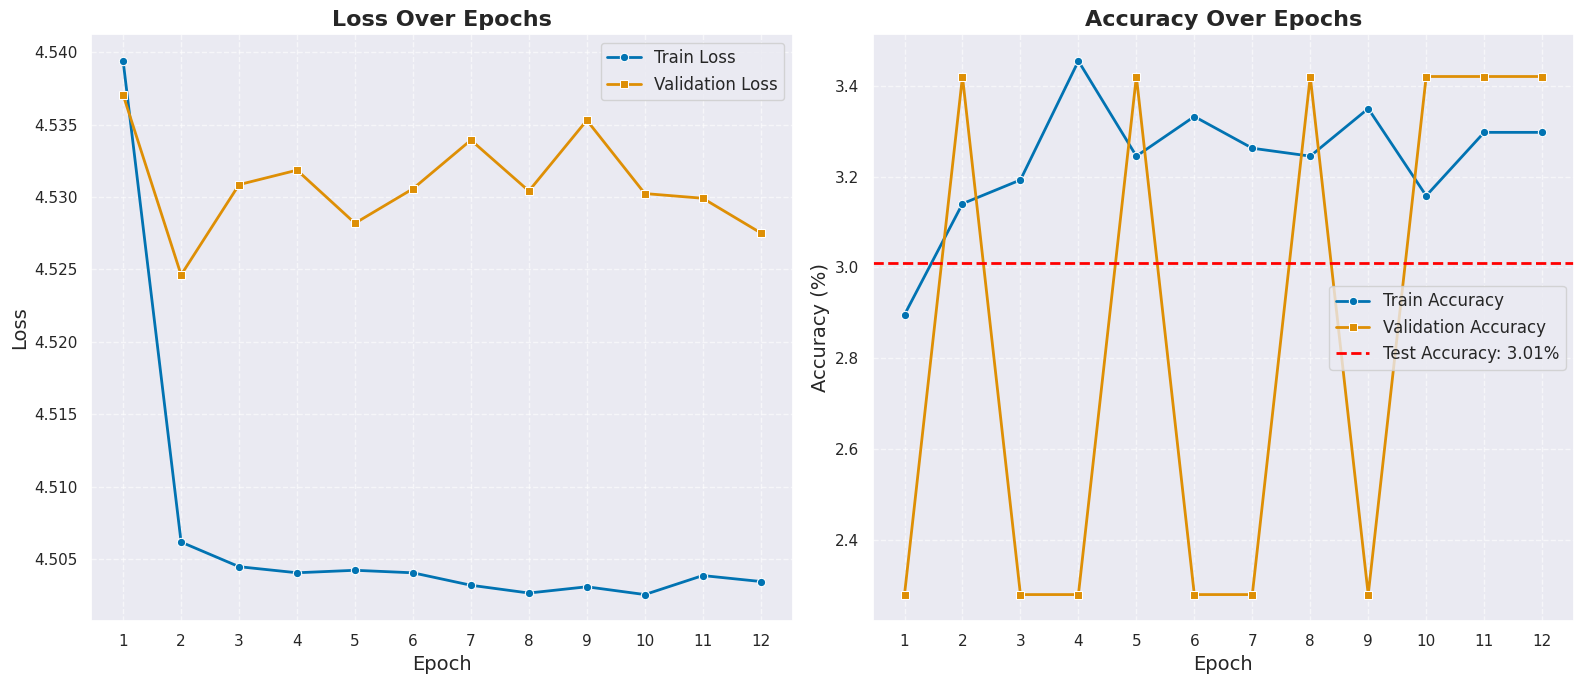

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

class BasicCNNModel(nn.Module):
    def __init__(self, num_classes):
        super(BasicCNNModel, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 6 * 6, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x / 255.0
        x = self.features(x)
        x = self.classifier(x)
        return x
class Flower102SGDClassifier(Flower102Classifier):
    def _build_model(self, num_classes):
        return BasicCNNModel(num_classes)

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.optimizer = optim.SGD(self.model.parameters(), lr=0.2, momentum=0.9, weight_decay=0.0)
sgd_classifier = Flower102SGDClassifier(
    data, image_dir='jpg',
    train_pct=0.7, val_pct=0.15, test_pct=0.15,
    batch_size=64, learning_rate=0.2,
    num_epochs=15, early_stop_patience=10
)

sgd_classifier.train()
sgd_classifier.test()
sgd_classifier.plot_training()



**Another Optimizers**

In [19]:
import random
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim import RMSprop, AdamW, NAdam

class Flower102MultiOptimizerClassifier:
    def __init__(self, data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                 batch_size=64, learning_rate=0.001, num_epochs=30, early_stop_patience=5,
                 optimizer_name='rmsprop'):
        assert abs(train_pct + val_pct + test_pct - 1.0) < 1e-6
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.early_stop_patience = early_stop_patience
        self.image_dir = image_dir

        random.seed(42)
        random.shuffle(data)
        n = len(data)
        train_end = int(train_pct * n)
        val_end = train_end + int(val_pct * n)
        self.train_data = data[:train_end]
        self.val_data = data[train_end:val_end]
        self.test_data = data[val_end:]

        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.train_dataset = Flowers102Dataset(self.train_data, image_dir, transform)
        self.val_dataset = Flowers102Dataset(self.val_data, image_dir, transform)
        self.test_dataset = Flowers102Dataset(self.test_data, image_dir, transform)

        self.train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        self.val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        self.test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

        num_classes = len(set(label for _, label in data))
        self.model = self._build_model(num_classes)

        # Set optimizer
        if optimizer_name == 'rmsprop':
            self.optimizer = RMSprop(self.model.parameters(), lr=learning_rate)
        elif optimizer_name == 'adamw':
            self.optimizer = AdamW(self.model.parameters(), lr=learning_rate)
        elif optimizer_name == 'nadam':
            self.optimizer = NAdam(self.model.parameters(), lr=learning_rate)
        else:
            raise ValueError(f"Unsupported optimizer: {optimizer_name}")

        self.loss_fn = nn.CrossEntropyLoss()

    def _build_model(self, num_classes):
        return nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def _train_one_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        for images, labels in self.train_loader:
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_fn(outputs, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.train_loader), 100 * correct / len(self.train_loader.dataset)

    def _validate_one_epoch(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in self.val_loader:
                outputs = self.model(images)
                loss = self.loss_fn(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.val_loader), 100 * correct / len(self.val_loader.dataset)

    def train(self):
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_state = None

        for epoch in (pbar := trange(self.num_epochs)):
            train_loss, train_acc = self._train_one_epoch()
            val_loss, val_acc = self._validate_one_epoch()
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_acc)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_acc)
            pbar.set_description(f"Train Loss: {train_loss:.3f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.3f} Acc: {val_acc:.2f}%")
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                best_model_state = copy.deepcopy(self.model.state_dict())
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= self.early_stop_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                break
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

    def test(self):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                outputs = self.model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        accuracy = 100 * correct / len(self.test_loader.dataset)
        print(f'Test accuracy: {accuracy:.2f}%')
        self.test_accuracy = accuracy
        return accuracy

    def plot_training(self):
        sns.set(style="darkgrid", palette="colorblind")
        epochs = np.arange(1, len(self.train_losses) + 1)
        plt.figure(figsize=(16, 7))
        plt.subplot(1, 2, 1)
        sns.lineplot(x=epochs, y=self.train_losses, marker="o", label='Train Loss', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_losses, marker="s", label='Validation Loss', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Loss', fontsize=14)
        plt.title('Loss Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.subplot(1, 2, 2)
        sns.lineplot(x=epochs, y=self.train_accuracies, marker="o", label='Train Accuracy', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_accuracies, marker="s", label='Validation Accuracy', linewidth=2)
        if hasattr(self, 'test_accuracy'):
            plt.axhline(y=self.test_accuracy, color='red', linestyle='--', label=f'Test Accuracy: {self.test_accuracy:.2f}%', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Accuracy (%)', fontsize=14)
        plt.title('Accuracy Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()


Training with RMSPROP optimizer


Train Loss: 0.852 Acc: 76.03% | Val Loss: 3.057 Acc: 34.61%:  60%|██████    | 9/15 [05:04<03:23, 33.87s/it]


Early stopping triggered after 10 epochs.


Test accuracy: 31.24%


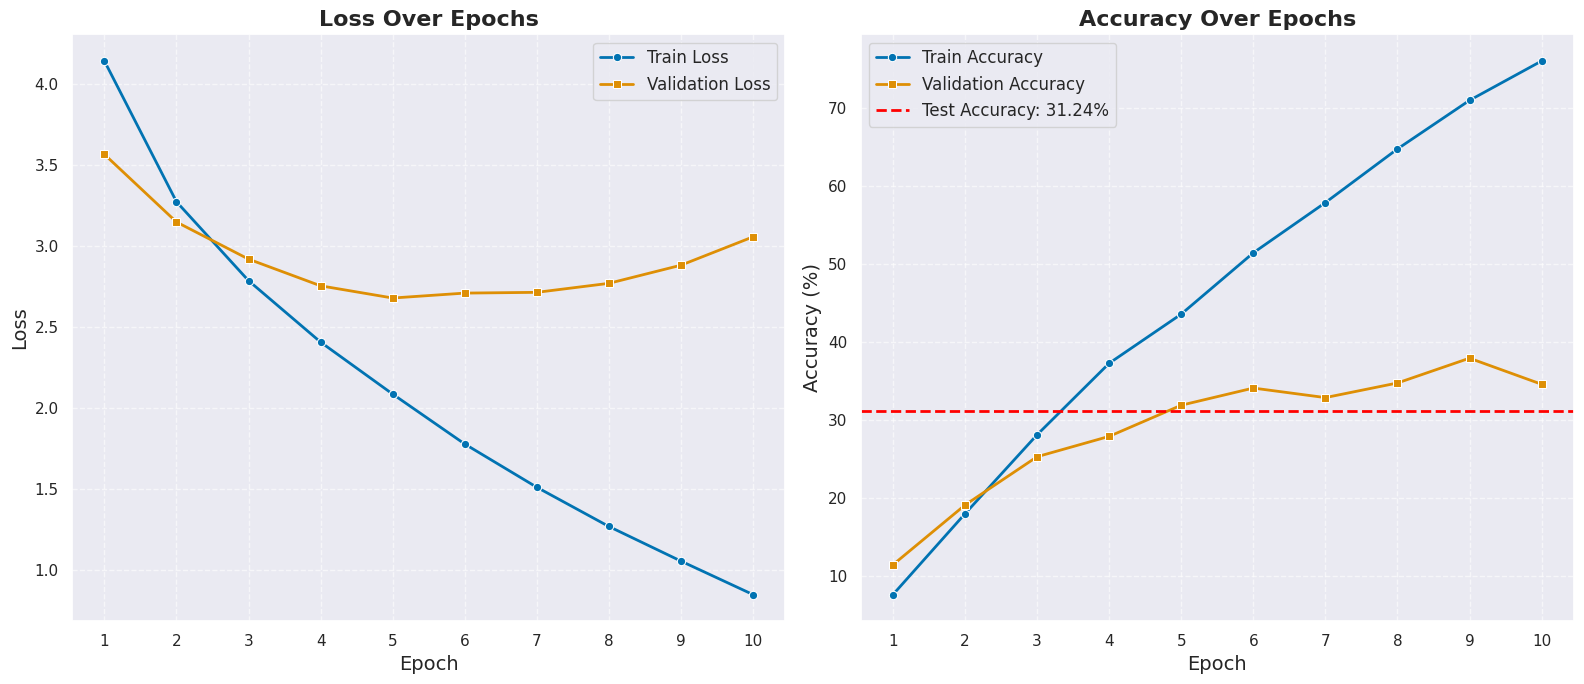


Training with ADAMW optimizer


Train Loss: 0.475 Acc: 85.90% | Val Loss: 3.419 Acc: 38.19%:  67%|██████▋   | 10/15 [05:41<02:50, 34.12s/it]


Early stopping triggered after 11 epochs.


Test accuracy: 39.79%


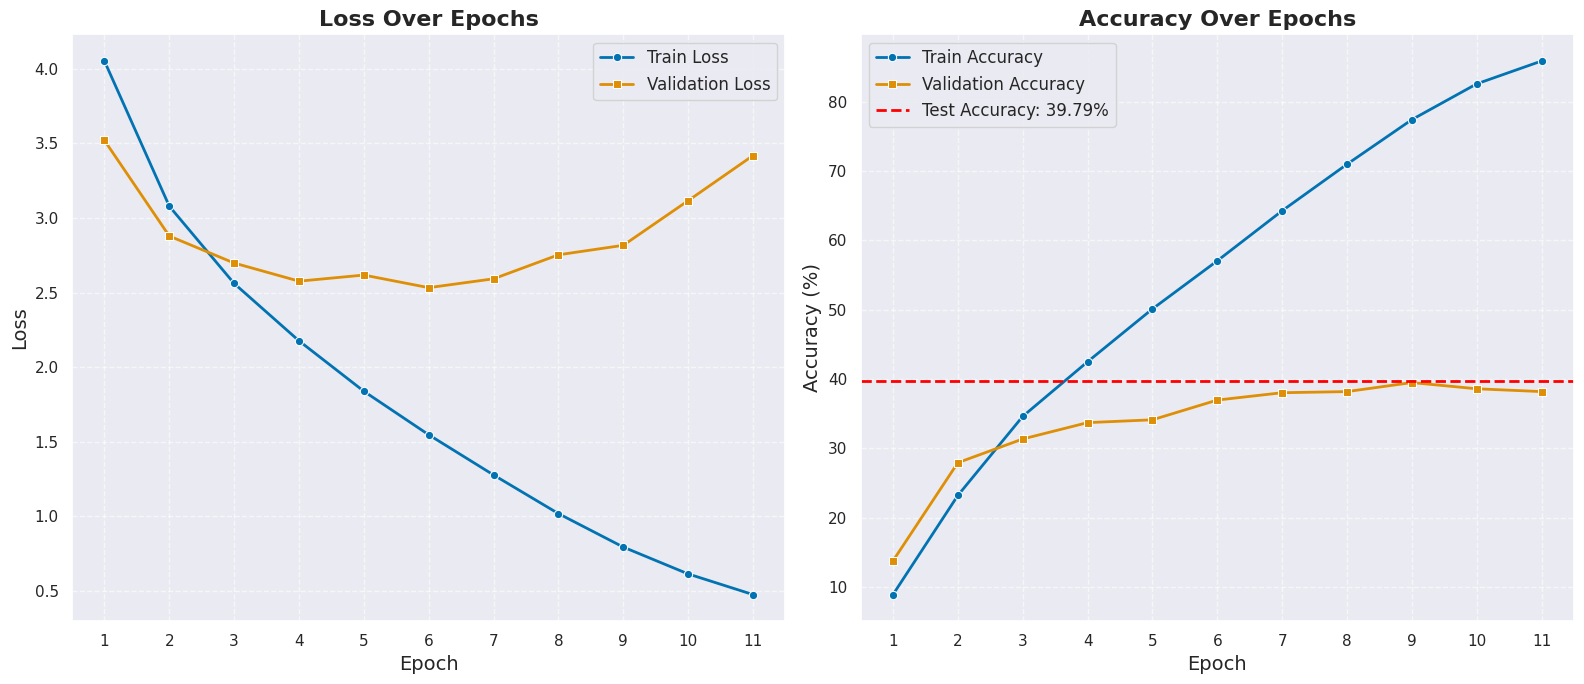


Training with NADAM optimizer


Train Loss: 0.301 Acc: 91.91% | Val Loss: 3.868 Acc: 36.97%:  67%|██████▋   | 10/15 [05:37<02:48, 33.72s/it]


Early stopping triggered after 11 epochs.


Test accuracy: 35.15%


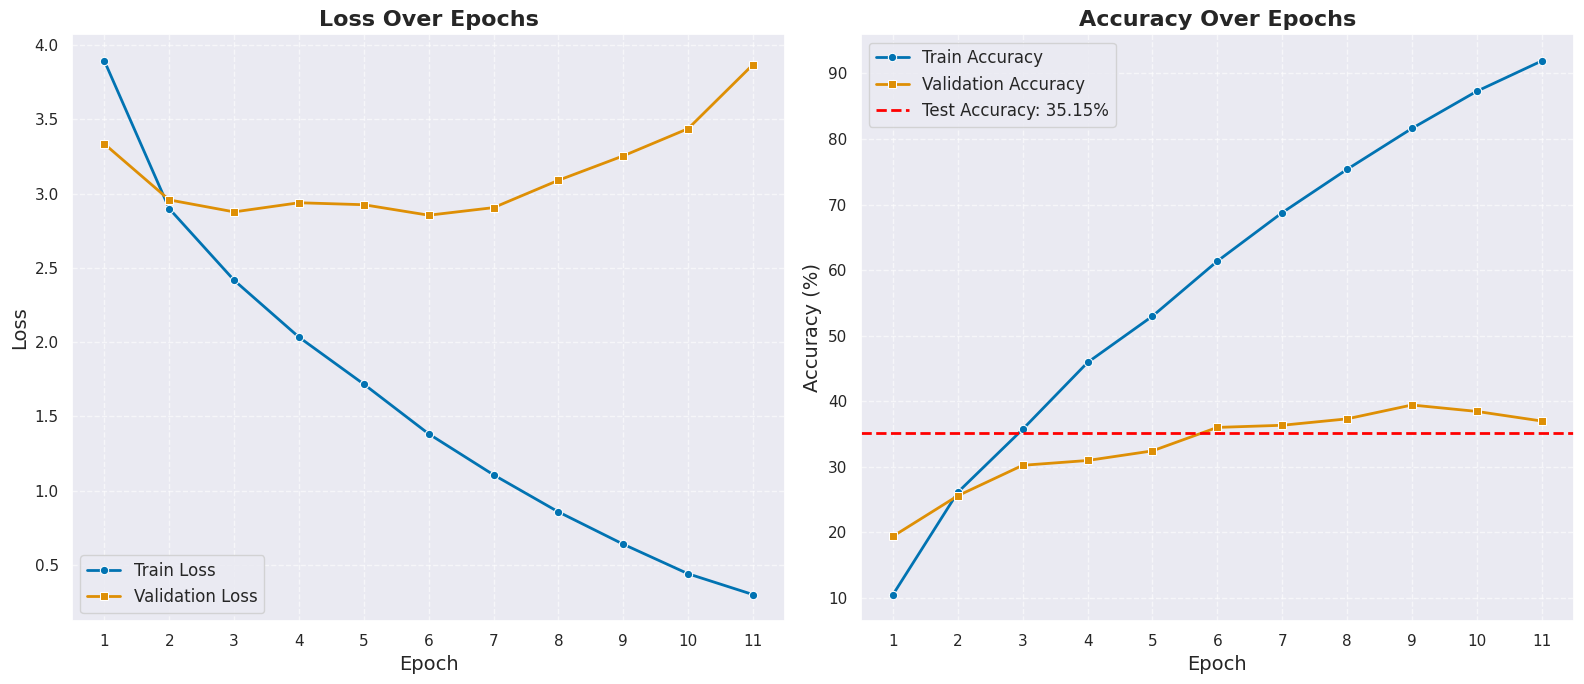

In [21]:
for opt in ['rmsprop', 'adamw', 'nadam']:
    print(f"\nTraining with {opt.upper()} optimizer")
    classifier = Flower102MultiOptimizerClassifier(data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                                     batch_size=64, num_epochs=15, early_stop_patience=5,
                                     optimizer_name=opt)
    classifier.train()
    classifier.test()
    classifier.plot_training()


**Dropout and momentum**

In [2]:
import random
import copy
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import trange
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

class Flower102AdamWClassifier:
    def __init__(self, data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                 batch_size=64, learning_rate=0.001, num_epochs=30, early_stop_patience=5,
                 momentum_dropout_combos=[(0.9, 0.3), (0.95, 0.5), (0.85, 0.2)]):
        assert abs(train_pct + val_pct + test_pct - 1.0) < 1e-6
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.early_stop_patience = early_stop_patience
        self.image_dir = image_dir
        self.momentum_dropout_combos = momentum_dropout_combos

        random.seed(42)
        random.shuffle(data)
        n = len(data)
        train_end = int(train_pct * n)
        val_end = train_end + int(val_pct * n)
        self.train_data = data[:train_end]
        self.val_data = data[train_end:val_end]
        self.test_data = data[val_end:]

        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.train_dataset = Flowers102Dataset(self.train_data, image_dir, transform)
        self.val_dataset = Flowers102Dataset(self.val_data, image_dir, transform)
        self.test_dataset = Flowers102Dataset(self.test_data, image_dir, transform)

        self.train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        self.val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        self.test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

        self.num_classes = len(set(label for _, label in data))
        self.results = []

    def _build_model(self, num_classes, momentum, dropout):
        return nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def _train_one_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        for images, labels in self.train_loader:
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_fn(outputs, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.train_loader), 100 * correct / len(self.train_loader.dataset)

    def _validate_one_epoch(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in self.val_loader:
                outputs = self.model(images)
                loss = self.loss_fn(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.val_loader), 100 * correct / len(self.val_loader.dataset)

    def train_and_evaluate_all(self):
        self.loss_fn = nn.CrossEntropyLoss()
        for momentum, dropout in self.momentum_dropout_combos:
            print(f"\nTraining with momentum={momentum}, dropout={dropout}")
            self.model = self._build_model(self.num_classes, momentum, dropout)
            self.optimizer = AdamW(self.model.parameters(), lr=self.learning_rate, betas=(momentum, 0.999))

            best_val_loss = float('inf')
            epochs_no_improve = 0
            best_model_state = None

            self.train_losses = []
            self.val_losses = []
            self.train_accuracies = []
            self.val_accuracies = []

            for epoch in (pbar := trange(self.num_epochs)):
                train_loss, train_acc = self._train_one_epoch()
                val_loss, val_acc = self._validate_one_epoch()

                self.train_losses.append(train_loss)
                self.val_losses.append(val_loss)
                self.train_accuracies.append(train_acc)
                self.val_accuracies.append(val_acc)

                pbar.set_description(f"Train Loss: {train_loss:.3f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.3f} Acc: {val_acc:.2f}%")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    epochs_no_improve = 0
                    best_model_state = copy.deepcopy(self.model.state_dict())
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= self.early_stop_patience:
                    print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                    break

            if best_model_state is not None:
                self.model.load_state_dict(best_model_state)

            self.test_accuracy = self.test()
            self.results.append((momentum, dropout, self.test_accuracy))
            self.plot_training()

    def test(self):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                outputs = self.model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        accuracy = 100 * correct / len(self.test_loader.dataset)
        print(f'Test accuracy: {accuracy:.2f}%')
        return accuracy

    def plot_training(self):
        sns.set(style="darkgrid", palette="colorblind")
        epochs = np.arange(1, len(self.train_losses) + 1)
        plt.figure(figsize=(16, 7))
        plt.subplot(1, 2, 1)
        sns.lineplot(x=epochs, y=self.train_losses, marker="o", label='Train Loss', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_losses, marker="s", label='Validation Loss', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Loss', fontsize=14)
        plt.title('Loss Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.subplot(1, 2, 2)
        sns.lineplot(x=epochs, y=self.train_accuracies, marker="o", label='Train Accuracy', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_accuracies, marker="s", label='Validation Accuracy', linewidth=2)
        if hasattr(self, 'test_accuracy'):
            plt.axhline(y=self.test_accuracy, color='red', linestyle='--', label=f'Test Accuracy: {self.test_accuracy:.2f}%', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Accuracy (%)', fontsize=14)
        plt.title('Accuracy Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()



Training with momentum=0.9, dropout=0.3


Train Loss: 1.196 Acc: 63.97% | Val Loss: 2.581 Acc: 40.96%:  93%|█████████▎| 14/15 [07:42<00:33, 33.02s/it]


Early stopping triggered after 15 epochs.


Test accuracy: 40.11%


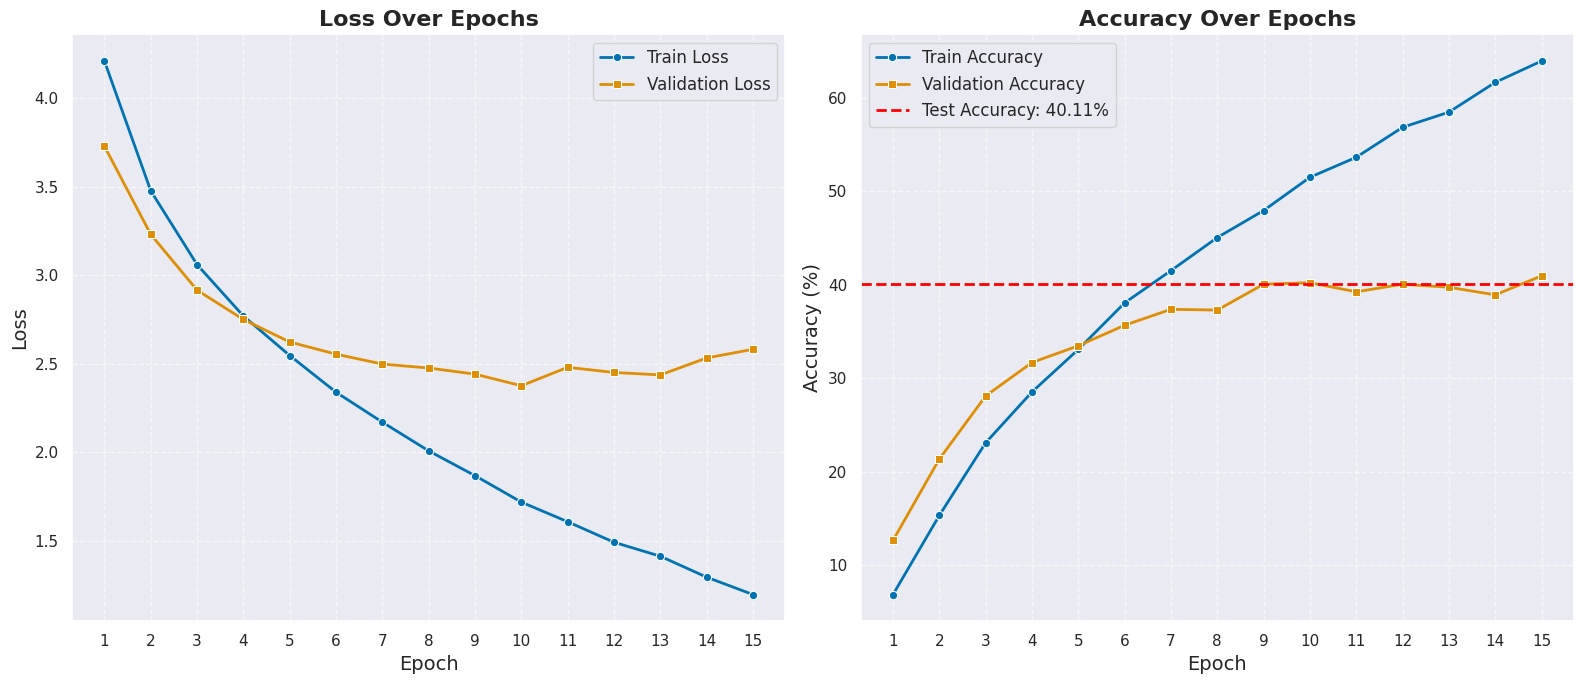


Training with momentum=0.95, dropout=0.5


Train Loss: 1.923 Acc: 44.98% | Val Loss: 2.515 Acc: 37.38%: 100%|██████████| 15/15 [07:40<00:00, 30.67s/it]


Test accuracy: 37.51%


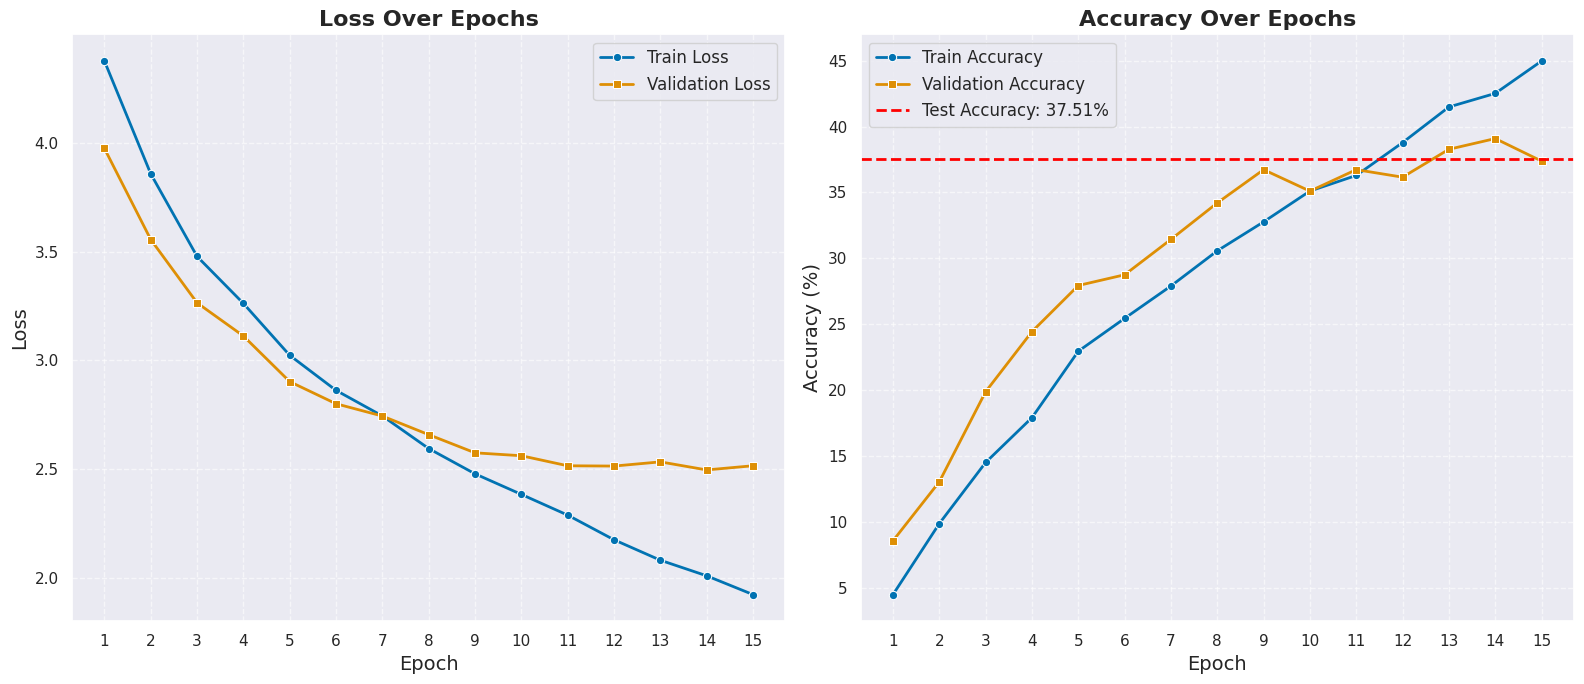


Training with momentum=0.85, dropout=0.2


Train Loss: 1.406 Acc: 59.96% | Val Loss: 2.456 Acc: 38.84%:  53%|█████▎    | 8/15 [04:34<03:33, 30.44s/it]

In [ ]:
classifier = Flower102AdamWClassifier(data, image_dir,
                                     momentum_dropout_combos=[(0.9, 0.3), (0.95, 0.5), (0.85, 0.2)],
                                     num_epochs=15, early_stop_patience=5)
classifier.train_and_evaluate_all()
momentums = [m for m, d, acc in classifier.results]
dropouts = [d for m, d, acc in classifier.results]
accuracies = [acc for m, d, acc in classifier.results]
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
scatter = plt.scatter(momentums, dropouts, c=accuracies, cmap='viridis', s=150, edgecolors='k')
plt.colorbar(scatter, label='Test Accuracy (%)')
plt.xlabel('Momentum (beta1)')
plt.ylabel('Dropout Probability')
plt.title('Test Accuracy by Momentum and Dropout (AdamW)')
for i, (m, d, acc) in enumerate(classifier.results):
    plt.text(m, d, f"{acc:.1f}%", fontsize=9, ha='center', va='bottom')
plt.show()



Training with momentum=0.85, dropout=0.2


Train Loss: 0.849 Acc: 73.71% | Val Loss: 2.791 Acc: 38.93%:  87%|████████▋ | 13/15 [06:14<00:57, 28.77s/it]


Early stopping triggered after 14 epochs.


Test accuracy: 39.06%


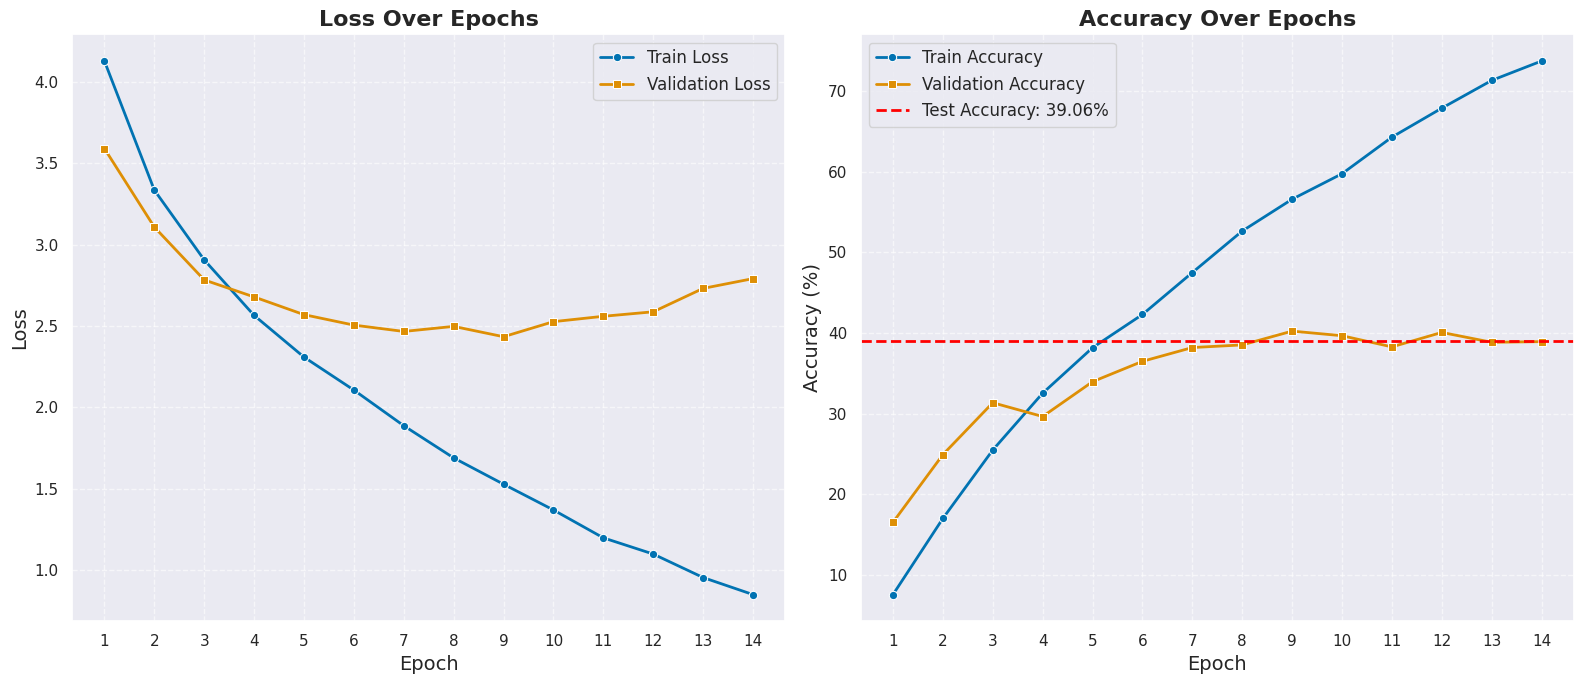

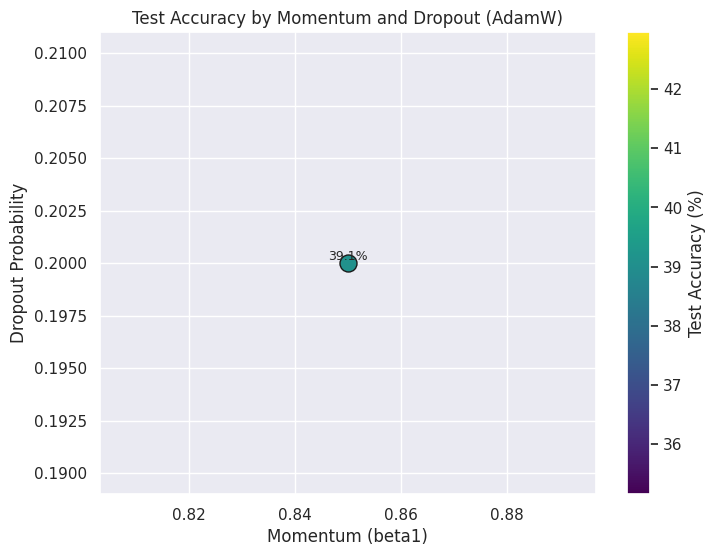

In [6]:
classifier = Flower102AdamWClassifier(data, image_dir,
                                     momentum_dropout_combos=[(0.85, 0.2)],
                                     num_epochs=15, early_stop_patience=5)
classifier.train_and_evaluate_all()
momentums = [m for m, d, acc in classifier.results]
dropouts = [d for m, d, acc in classifier.results]
accuracies = [acc for m, d, acc in classifier.results]
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
scatter = plt.scatter(momentums, dropouts, c=accuracies, cmap='viridis', s=150, edgecolors='k')
plt.colorbar(scatter, label='Test Accuracy (%)')
plt.xlabel('Momentum (beta1)')
plt.ylabel('Dropout Probability')
plt.title('Test Accuracy by Momentum and Dropout (AdamW)')
for i, (m, d, acc) in enumerate(classifier.results):
    plt.text(m, d, f"{acc:.1f}%", fontsize=9, ha='center', va='bottom')
plt.show()


In [10]:
import random
import copy
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import trange
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

class Flower102RegularizedClassifier:
    def __init__(self, data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                 batch_size=64, learning_rate=0.001, num_epochs=15, early_stop_patience=5,
                 momentum=0.9, dropout=0.3, weight_decay=1e-4):
        assert abs(train_pct + val_pct + test_pct - 1.0) < 1e-6
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.early_stop_patience = early_stop_patience
        self.image_dir = image_dir
        self.momentum = momentum
        self.dropout = dropout
        self.weight_decay = weight_decay

        random.seed(42)
        random.shuffle(data)
        n = len(data)
        train_end = int(train_pct * n)
        val_end = train_end + int(val_pct * n)
        self.train_data = data[:train_end]
        self.val_data = data[train_end:val_end]
        self.test_data = data[val_end:]

        transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.train_dataset = Flowers102Dataset(self.train_data, image_dir, transform)
        self.val_dataset = Flowers102Dataset(self.val_data, image_dir, transform)
        self.test_dataset = Flowers102Dataset(self.test_data, image_dir, transform)

        self.train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        self.val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        self.test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

        self.num_classes = len(set(label for _, label in data))
        self.results = []

    def _build_model(self, num_classes, dropout):
        return nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def _train_one_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        for images, labels in self.train_loader:
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_fn(outputs, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.train_loader), 100 * correct / len(self.train_loader.dataset)

    def _validate_one_epoch(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in self.val_loader:
                outputs = self.model(images)
                loss = self.loss_fn(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.val_loader), 100 * correct / len(self.val_loader.dataset)

    def train_and_evaluate(self):
        self.loss_fn = nn.CrossEntropyLoss()
        print(f"\nTraining with momentum={self.momentum}, dropout={self.dropout}, weight_decay={self.weight_decay}")
        self.model = self._build_model(self.num_classes, self.dropout)
        self.optimizer = AdamW(
            self.model.parameters(),
            lr=self.learning_rate,
            betas=(self.momentum, 0.999),
            weight_decay=self.weight_decay
        )

        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_state = None

        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

        for epoch in (pbar := trange(self.num_epochs)):
            train_loss, train_acc = self._train_one_epoch()
            val_loss, val_acc = self._validate_one_epoch()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)

            pbar.set_description(f"Train Loss: {train_loss:.3f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.3f} Acc: {val_acc:.2f}%")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                best_model_state = copy.deepcopy(self.model.state_dict())
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= self.early_stop_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                break

        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

        self.test_accuracy = self.test()
        self.results.append((self.momentum, self.dropout, self.test_accuracy))
        self.plot_training()

    def test(self):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                outputs = self.model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        accuracy = 100 * correct / len(self.test_loader.dataset)
        print(f'Test accuracy: {accuracy:.2f}%')
        return accuracy

    def plot_training(self):
        sns.set(style="darkgrid", palette="colorblind")
        epochs = np.arange(1, len(self.train_losses) + 1)
        plt.figure(figsize=(16, 7))
        plt.subplot(1, 2, 1)
        sns.lineplot(x=epochs, y=self.train_losses, marker="o", label='Train Loss', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_losses, marker="s", label='Validation Loss', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Loss', fontsize=14)
        plt.title('Loss Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.subplot(1, 2, 2)
        sns.lineplot(x=epochs, y=self.train_accuracies, marker="o", label='Train Accuracy', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_accuracies, marker="s", label='Validation Accuracy', linewidth=2)
        if hasattr(self, 'test_accuracy'):
            plt.axhline(y=self.test_accuracy, color='red', linestyle='--', label=f'Test Accuracy: {self.test_accuracy:.2f}%', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Accuracy (%)', fontsize=14)
        plt.title('Accuracy Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()



Training with momentum=0.9, dropout=0.3, weight_decay=0.0001


Train Loss: 1.219 Acc: 63.96% | Val Loss: 2.528 Acc: 40.15%:  93%|█████████▎| 14/15 [06:14<00:26, 26.78s/it]


Early stopping triggered after 15 epochs.


Test accuracy: 41.58%


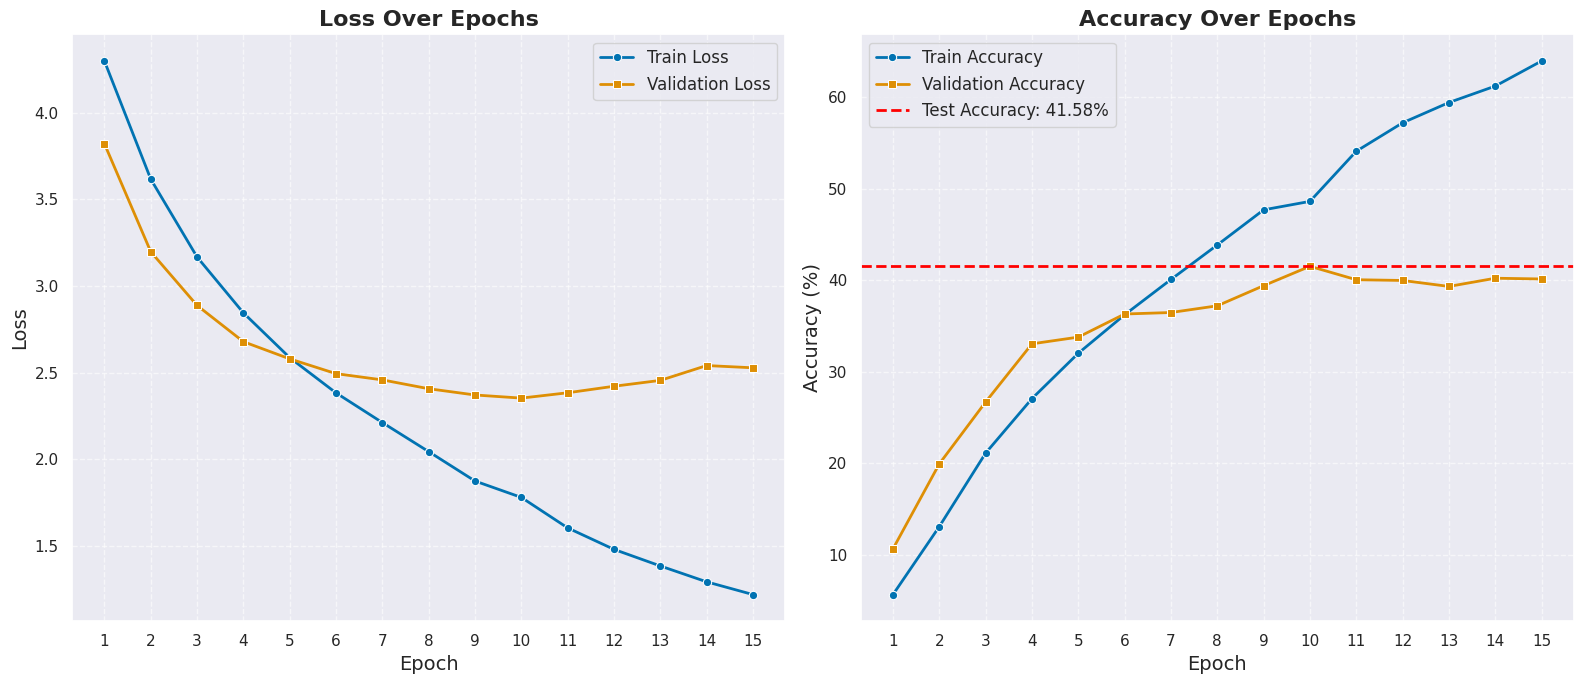

[(0.9, 0.3, 41.57851912123678)]


In [11]:
classifier = Flower102RegularizedClassifier(data=data, image_dir=image_dir)
classifier.train_and_evaluate()
print(classifier.results)


In [16]:
import torchvision.models as models

class Flower102AlexNetClassifier:
    def __init__(self, data, image_dir, train_pct=0.7, val_pct=0.15, test_pct=0.15,
                 batch_size=64, learning_rate=0.001, num_epochs=15, early_stop_patience=5,
                 momentum=0.9, dropout=0.3, weight_decay=1e-4):
        assert abs(train_pct + val_pct + test_pct - 1.0) < 1e-6
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.early_stop_patience = early_stop_patience
        self.image_dir = image_dir
        self.momentum = momentum
        self.dropout = dropout
        self.weight_decay = weight_decay

        random.seed(42)
        random.shuffle(data)
        n = len(data)
        train_end = int(train_pct * n)
        val_end = train_end + int(val_pct * n)
        self.train_data = data[:train_end]
        self.val_data = data[train_end:val_end]
        self.test_data = data[val_end:]

        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.train_dataset = Flowers102Dataset(self.train_data, image_dir, transform)
        self.val_dataset = Flowers102Dataset(self.val_data, image_dir, transform)
        self.test_dataset = Flowers102Dataset(self.test_data, image_dir, transform)

        self.train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
        self.val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        self.test_loader = DataLoader(self.test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

        self.num_classes = len(set(label for _, label in data))
        self.results = []

    def _build_model(self, num_classes, dropout):
        alexnet = models.alexnet(pretrained=True)
        for param in alexnet.features.parameters():
            param.requires_grad = False
        alexnet.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )
        return alexnet

    def _train_one_epoch(self):
        self.model.train()
        total_loss = 0
        correct = 0
        for images, labels in self.train_loader:
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_fn(outputs, labels)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.train_loader), 100 * correct / len(self.train_loader.dataset)

    def _validate_one_epoch(self):
        self.model.eval()
        total_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in self.val_loader:
                outputs = self.model(images)
                loss = self.loss_fn(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
        return total_loss / len(self.val_loader), 100 * correct / len(self.val_loader.dataset)

    def train_and_evaluate(self):
        self.loss_fn = nn.CrossEntropyLoss()
        print(f"\nTraining with momentum={self.momentum}, dropout={self.dropout}, weight_decay={self.weight_decay}")
        self.model = self._build_model(self.num_classes, self.dropout)
        self.optimizer = AdamW(
            self.model.parameters(),
            lr=self.learning_rate,
            betas=(self.momentum, 0.999),
            weight_decay=self.weight_decay
        )

        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_model_state = None

        self.train_losses = []
        self.val_losses = []
        self.train_accuracies = []
        self.val_accuracies = []

        for epoch in (pbar := trange(self.num_epochs)):
            train_loss, train_acc = self._train_one_epoch()
            val_loss, val_acc = self._validate_one_epoch()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accuracies.append(train_acc)
            self.val_accuracies.append(val_acc)

            pbar.set_description(f"Train Loss: {train_loss:.3f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.3f} Acc: {val_acc:.2f}%")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                best_model_state = copy.deepcopy(self.model.state_dict())
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= self.early_stop_patience:
                print(f"\nEarly stopping triggered after {epoch+1} epochs.")
                break

        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)

        self.test_accuracy = self.test()
        self.results.append((self.momentum, self.dropout, self.test_accuracy))
        self.plot_training()

    def test(self):
        self.model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                outputs = self.model(images)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        accuracy = 100 * correct / len(self.test_loader.dataset)
        print(f'Test accuracy: {accuracy:.2f}%')
        return accuracy

    def plot_training(self):
        sns.set(style="darkgrid", palette="colorblind")
        epochs = np.arange(1, len(self.train_losses) + 1)
        plt.figure(figsize=(16, 7))
        plt.subplot(1, 2, 1)
        sns.lineplot(x=epochs, y=self.train_losses, marker="o", label='Train Loss', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_losses, marker="s", label='Validation Loss', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Loss', fontsize=14)
        plt.title('Loss Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.subplot(1, 2, 2)
        sns.lineplot(x=epochs, y=self.train_accuracies, marker="o", label='Train Accuracy', linewidth=2)
        sns.lineplot(x=epochs, y=self.val_accuracies, marker="s", label='Validation Accuracy', linewidth=2)
        if hasattr(self, 'test_accuracy'):
            plt.axhline(y=self.test_accuracy, color='red', linestyle='--', label=f'Test Accuracy: {self.test_accuracy:.2f}%', linewidth=2)
        plt.xlabel('Epoch', fontsize=14)
        plt.ylabel('Accuracy (%)', fontsize=14)
        plt.title('Accuracy Over Epochs', fontsize=16, fontweight='bold')
        plt.xticks(epochs)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()



Training with momentum=0.9, dropout=0.3, weight_decay=0.0001


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:01<00:00, 170MB/s]
Train Loss: 0.315 Acc: 91.49% | Val Loss: 1.002 Acc: 76.71%:  73%|███████▎  | 11/15 [48:24<17:36, 264.02s/it]


Early stopping triggered after 12 epochs.


Test accuracy: 79.41%


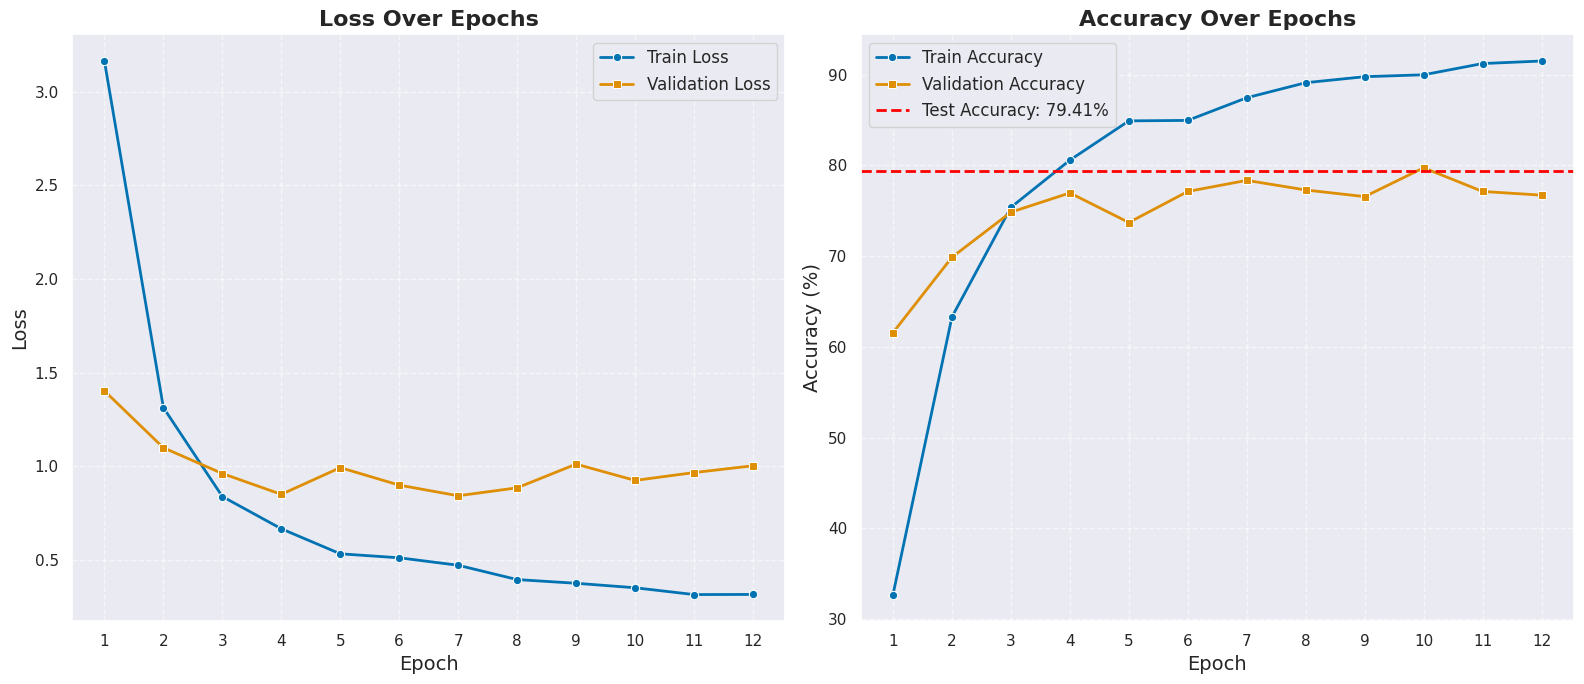

[(0.9, 0.3, 79.41415785191212)]


In [17]:
classifier = Flower102AlexNetClassifier(data=data, image_dir=image_dir)
classifier.train_and_evaluate()
print(classifier.results)